In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calplot
import json
import plotly.express as px
import plotly.graph_objects as go
import builtins
import numpy as np

# Final Project: Assignment B - "The Viz and the Notebook"

*Social Data Analysis, Spring 2026 <br>*

*Diogo Forte* and *Maria Vendas*

# 1. Motivation

Housing is one of the most direct expressions of inequality since where you live determines the quality of your home, and whether or how fast the city responds to issues. The goal of this project is to see if housing conditions in New York City are systematically worse in lower-income neighborhoods. Concretely, we want to understand how complaints and violations are distributed across the city, what are the problems being reported, their severity and how long they take to be resolved. Furthermore, we also investigate if certain landlords consistently accumulate housing problems across multiple buildings and see if these situations are explained by where in the income distribution a neighborhood is. <br>


This project combines five datasets from two sources: NYC Open Data [1] and the U.S. Census Bureau [2]. The data was fetched using `build_datasets.ipynb` notebook and saved on the `data` folder as `.csv` files, to then be used for analysis. <br>

The final datasets are: <br>

1. **Complaints (2021–2025)** `complaints21_25_original.csv`

The dataset was fetched from the **311 Service Requests from 2020 to Present** dataset [3] on NYC Open Data. It comprises complaints filed by residents through NYC's 311 system, capturing what residents report, not a formal evaluation. The data was filtered at fetch time to only keep records from the Department of Housing Preservation and Development (HPD) from 2021 to 2025, keeping the fields *date filed*, *borough*, *zip code* and *complaint category*. The complaint categories were restricted to the five most critical types: heat/hot water, unsanitary conditions, water leak, plumbing and electrical.

2. **Violations (2021–2025)** `violations21_25_original.csv`

The data was fetched from the **Housing Maintenance Code Violations** dataset [4] on NYC Open Data. The records are formal violations issued by HPD after an inspection of a residential building, filtered from 2021 to 2025 and including the *borough*, *zip code*, *violation class* (A, B or C by increasing severity), the *inspection date* (date the violation was opened), the *certified date* (date it was closed, if resolved) and the *status of the violation*, if it is closed or open.

3. **Buildings' Ownership Registrations** `registrations_original.csv`

Fetched from the **Multiple Dwelling Registrations** [5] dataset on NYC Open Data. The dataset has one record per registered building, including *zip code*, *borough*, *building ID*, and *registration ID*. In most cases, each Registration ID corresponds to one registration filing for one building. However, a Registration ID can also refer to multiple buildings if they belong to a *Garden Complex*. To identify buildings with the same owner, we can use the Registration Contacts dataset that has details for each Registration ID.

4. **Registration Contacts** `contacts_original.csv`

The data was fetched from **Registration Contacts** dataset [6] on NYC Open Data. It contains the names and contact details of the entity responsible for each registered building and it is linked to the Multiple Dwelling Registrations by a shared RegistrationID. This dataset makes it possible to examine patterns at the ownership level, for example, if certain landlords are associated with high violation numbers.

5. **Median Household Income by ZIP Code** · `nyc_zipcode_income.csv`

Fetched from the **American Community Survey (ACS) 5-Year Estimates, 2024** [7] via the U.S. Census Bureau API. The specific variable used is **S1901_C01_012E**, the estimated median household income in the past 12 months at the ZIP Code Tabulation Area (ZCTA) level. The data was fetched for all ZCTAs and then filtered to New York City using ZIP code prefixes as a proxy for borough: Manhattan with 100, 101 and 102; Bronx with 104; Brooklyn with 112; Queens with 110, 111, 113, 114 and 116; and Staten Island with 103. Census missing value codes (`-666666666`) were replaced with `NaN` and records with missing income were dropped, as these correspond to ZCTAs where the sample size was too small to produce a reliable estimate. The final dataset contains one row per NYC ZIP code with a valid median income estimate, used to correlate housing conditions with neighborhood income.

These datasets were chosen so we can aggregate them and tell a more holistic version of the housing situation in New York City. All of them are publicly accessible, consistently structured, and share common geographic identifiers (borough and zip code) that make joining easy.

The goal for the end user's experience was for a non-technical reader to get a clear understanding that housing inequality in New York City is not random and that it follows geographic patterns that persist every year in the dataset. Rather than presenting tables of statistics, the website tells the story progressively: starting with the scale of the problem, then what types of issues people face, how long they take to be resolved, and finally whether this correlates with neighborhood income.

# 2. Exploratory Data Analysis

## 2.1. Complaints

In [3]:
df_complaints=pd.read_csv("data/complaints21_25_original.csv")
df_complaints = df_complaints.drop(columns=["agency_name"])
df_complaints.head()

,unique_key,created_date,complaint_type,incident_zip,borough
0,67350845,2025-12-31 23:57:56,HEAT/HOT WATER,11229.0,BROOKLYN
1,67347338,2025-12-31 23:54:46,HEAT/HOT WATER,11239.0,BROOKLYN
2,67350847,2025-12-31 23:54:42,HEAT/HOT WATER,10040.0,MANHATTAN
3,67346000,2025-12-31 23:54:41,HEAT/HOT WATER,10463.0,MANHATTAN
4,67349568,2025-12-31 23:54:14,HEAT/HOT WATER,10454.0,BRONX


In [4]:
print("Missing values per column")
print(df_complaints.isna().sum())

Missing values per column
unique_key          0
created_date        0
complaint_type      0
incident_zip      334
borough             4
dtype: int64


Rows with missing values for zip are dropped since we will be analysing the dataset at the zip level and the number of missing values is not significant. The date variable was converted to pandas datetime format, to be easier to handle.

In [5]:
df_complaints = df_complaints.dropna()
print(f"Number of observations after droping NaN in zip: {len(df_complaints)}\n")

df_complaints["created_date"] = pd.to_datetime(df_complaints["created_date"], errors="coerce")
print(f"Rows with unparseable dates: {df_complaints['created_date'].isna().sum()}")
df_complaints["created_date"]=pd.to_datetime(df_complaints["created_date"]) #add smth for errors
print(f"Date range: {df_complaints["created_date"].min()}, {df_complaints["created_date"].max()}\n")

unique_comp=list(df_complaints["complaint_type"].unique())
print(f"Number of types of complaints: {len(unique_comp)}")
print(f"Types of compaints: {unique_comp}\n")

print(f"Number of different zipcodes: {len(df_complaints["incident_zip"].unique())}")
print(f"Number of different boroughs: {len(df_complaints["borough"].unique())}")
print(df_complaints["borough"].unique())

Number of observations after droping NaN in zip: 2468069

Rows with unparseable dates: 0
Date range: 2021-01-01 00:01:14, 2025-12-31 23:57:56

Number of types of complaints: 5
Types of compaints: ['HEAT/HOT WATER', 'PLUMBING', 'WATER LEAK', 'UNSANITARY CONDITION', 'ELECTRIC']

Number of different zipcodes: 211
Number of different boroughs: 5
<StringArray>
['BROOKLYN', 'MANHATTAN', 'BRONX', 'QUEENS', 'STATEN ISLAND']
Length: 5, dtype: str


Heat/hot water is clearly the type with more complaints, Bronx is the borough with more complaints, closely followed by Brooklyn. <br>

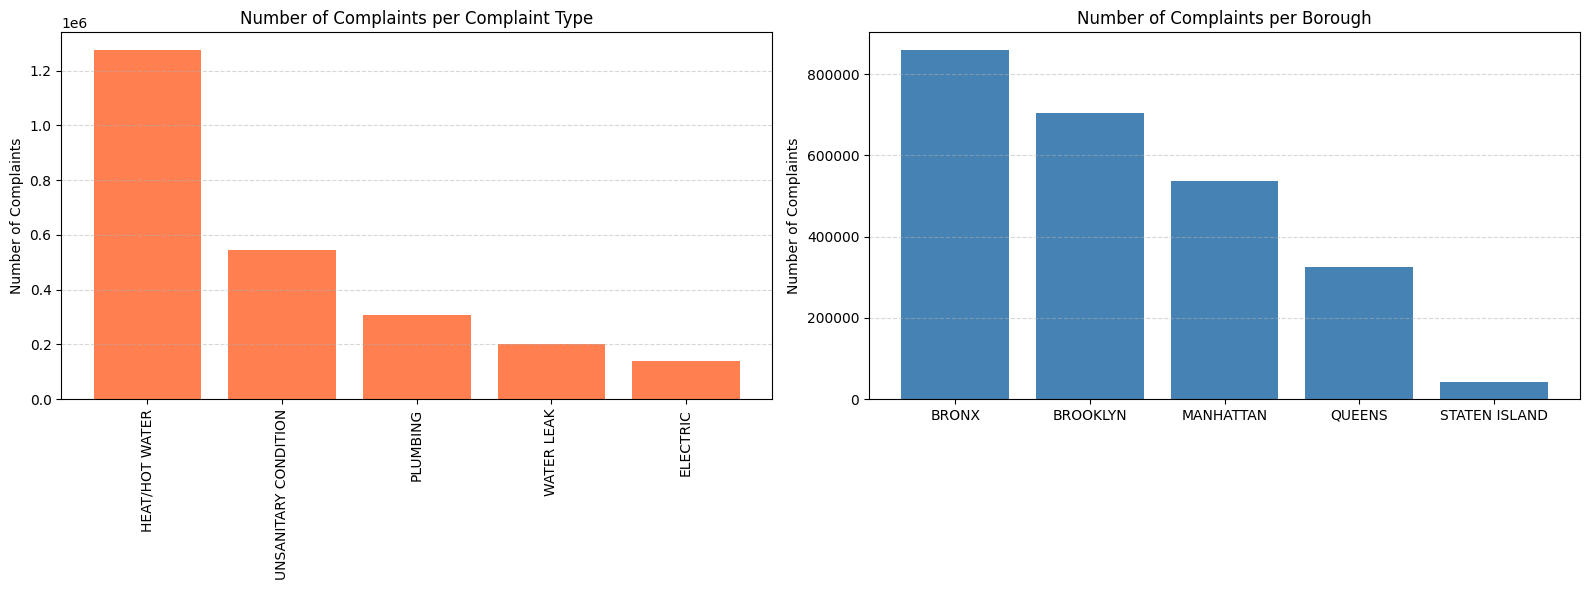

In [6]:
counts_type = df_complaints["complaint_type"].value_counts()
comp_borough = df_complaints["borough"].value_counts()

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.bar(counts_type.index, counts_type.values, color='coral')
plt.title("Number of Complaints per Complaint Type")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.bar(comp_borough.index, comp_borough.values, color='steelblue')
plt.title("Number of Complaints per Borough")
plt.ylabel("Number of Complaints")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Bronx and Brooklyn make up more than 50% of the complaints every year.

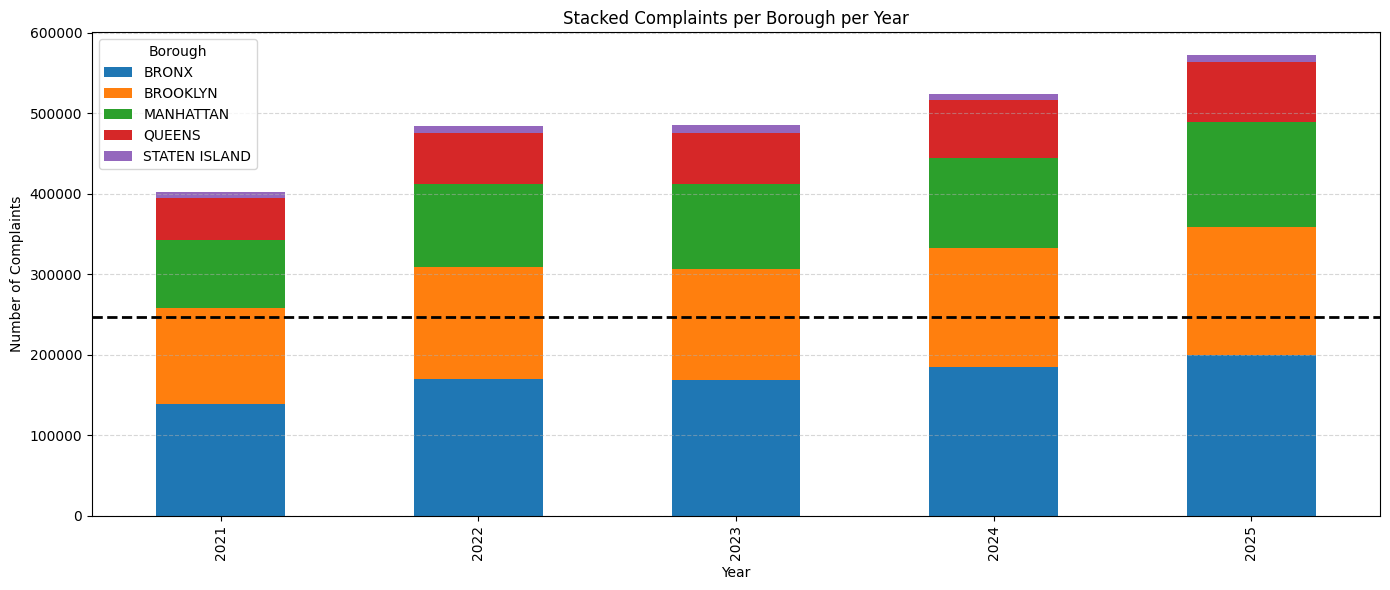

In [7]:
df_complaints["year"] = df_complaints["created_date"].dt.year
year_boro = df_complaints.groupby(["year", "borough"]).size().unstack(fill_value=0)
year_totals = year_boro.sum(axis=1)
ax = year_boro.plot(kind="bar", stacked=True, figsize=(14, 6))
ax.axhline(y=year_totals.mean() * 0.5, color="black", linestyle="--", linewidth=2)

plt.title("Stacked Complaints per Borough per Year")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Borough")
plt.tight_layout()
plt.show()

Across complaint types, Bronx and Brooklyn also have a higher number of complaints for every year.

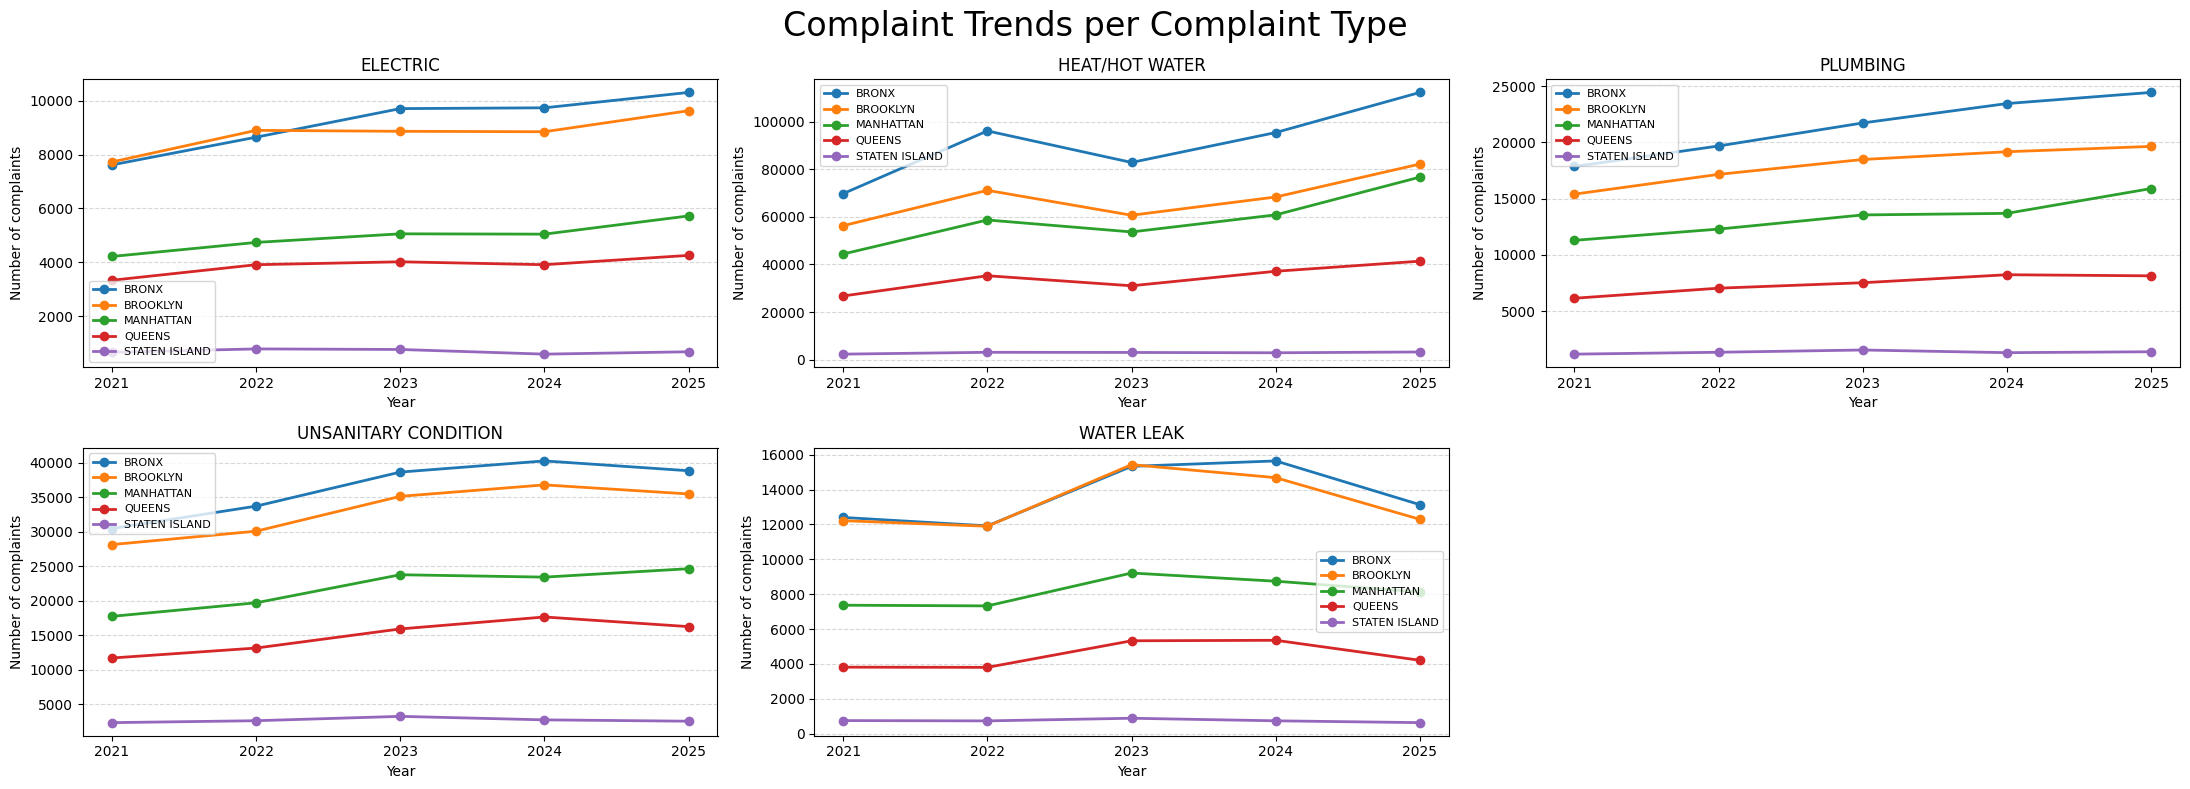

In [8]:
grouped = (df_complaints.groupby(["borough", "year", "complaint_type"]).size().reset_index(name="count"))
complaints = grouped["complaint_type"].unique()
years = sorted(grouped["year"].unique())

fig, axes = plt.subplots(2, 3, figsize=(22, 2 * 4))
axes = axes.flatten()

for i, comp in enumerate(complaints):
    ax = axes[i]
    df_c = grouped[grouped["complaint_type"] == comp]

    for borough in df_c["borough"].unique():
        df_b = df_c[df_c["borough"] == borough]
        ax.plot(df_b["year"], df_b["count"], marker='o', linewidth=2, label=borough)

    ax.set_title(comp)
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of complaints")
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_xticks(years)
    ax.legend(fontsize=8)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Complaint Trends per Complaint Type", fontsize=24)
plt.tight_layout()
plt.show()

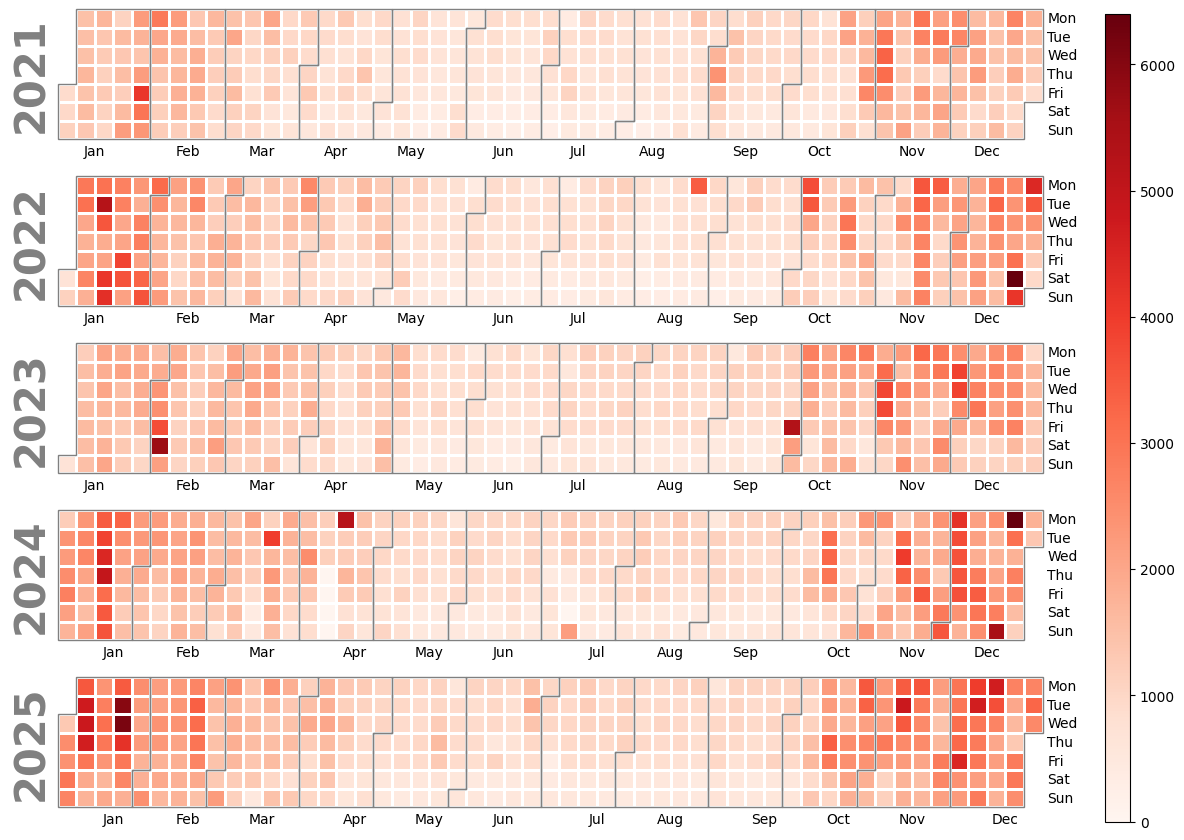

In [9]:
import logging
import matplotlib.font_manager as fm

# Temporarily silence the font manager logger
fm_logger = logging.getLogger('matplotlib.font_manager')
old_level = fm_logger.level
fm_logger.setLevel(logging.ERROR)

df_complaints["date"] = df_complaints["created_date"].dt.floor("D")
daily_counts = df_complaints.groupby("date").size()
calplot.calplot(daily_counts, cmap='Reds')
plt.show()

# Restore previous logging level
fm_logger.setLevel(old_level)

Overall, the complaints are grouped in the winter and mainly concern Heat/Hot water issues. Geographically, Bronx and Brooklyn consistently show a higher number of complaints than the other boroughs. These numbers must be evaluated against the population of each borough for a fair comparision.

## 2.2. Violations

In [10]:
df_violations=pd.read_csv("data/violations21_25_original.csv")
df_violations.head()

,violationid,zip,class,inspectiondate,certifieddate,boro,violationstatus,registrationid
0,18557284,10029.0,C,2025-12-31,NaN,MANHATTAN,Close,139824
1,18544168,10025.0,C,2025-12-31,NaN,MANHATTAN,Close,102933
2,18544150,11372.0,C,2025-12-31,NaN,QUEENS,Open,401100
3,18544144,11372.0,C,2025-12-31,NaN,QUEENS,Open,401100
4,18544049,10019.0,C,2025-12-31,NaN,MANHATTAN,Open,142112


In [11]:
print("Missing values per column")
print(df_violations.isna().sum())

Missing values per column
violationid              0
zip                   4369
class                    0
inspectiondate           0
certifieddate      2319858
boro                     0
violationstatus          0
registrationid           0
dtype: int64


Only remove rows with zip code as missing value, since missing values in certified date might just mean that the violation has not been certified/corrected yet, and keep only valid 5‑digit ZIP codes. <br>

Transform date into pandas datetime format and remove rows with wrongly formated dates, for example, months larger than 12, certified dates smaller than the inspection date.

In [12]:
# Zip
df_violations = df_violations.dropna(subset=["zip"])
df_violations["zip"] = df_violations["zip"].astype(int).astype(str)
df_violations = df_violations[df_violations["zip"].str.len() == 5]
df_violations["zip"] = df_violations["zip"].astype(int)
print(f"Number of observations after droping invalid and NaN zip codes: {len(df_violations)}\n")


# Date
df_violations["inspectiondate"]=pd.to_datetime(df_violations["inspectiondate"])
print(f"Date range: {df_violations["inspectiondate"].min()}, {df_violations["inspectiondate"].max()}")

min_date = pd.Timestamp("2000-01-01")
max_date = pd.Timestamp("today")
df_violations["certifieddate"]=pd.to_datetime(df_violations["certifieddate"])

bad_dates = df_violations[
    (df_violations["certifieddate"] < min_date) | (df_violations["certifieddate"] > max_date) |
    (df_violations["inspectiondate"] < min_date) | (df_violations["inspectiondate"] > max_date) |
    (df_violations["certifieddate"] < df_violations["inspectiondate"])
]

df_violations = df_violations[
    ~(
        (df_violations["certifieddate"] < min_date) | (df_violations["certifieddate"] > max_date) |
        (df_violations["inspectiondate"] < min_date) | (df_violations["inspectiondate"] > max_date) |
        (df_violations["certifieddate"] < df_violations["inspectiondate"])
    )
]

print(f"Number of observations after droping wrong date formats: {len(df_violations)}\n")


# Other vars
viol_class=list(df_violations["class"].unique())
print(f"Number of classes of violations: {len(viol_class)}")
print(f"Classes of violations: {viol_class}")
print(f"Number of different zipcodes: {len(df_violations["zip"].unique())}")
print(f"Number of different boroughs: {len(df_violations["boro"].unique())}")

Number of observations after droping invalid and NaN zip codes: 3993475

Date range: 2021-01-01 00:00:00, 2025-12-31 00:00:00
Number of observations after droping wrong date formats: 3993457

Number of classes of violations: 3
Classes of violations: ['C', 'B', 'A']
Number of different zipcodes: 189
Number of different boroughs: 5


Around 41% of the violations have a certified date meaning that 41% of the initial complaints were corrected. Then, for the violations with no certified date, 45% are still Open, which means they have not been addressed yet, while 54% are Closed, but with no certified date (probably due to errors, lack of rigour or if the building was demolished for example). So in our dataset, 26% of the violations have not been addressed yet.

In [13]:
no_viol=len(df_violations)
no_cd=df_violations["certifieddate"].isna().sum()
print(f"Number of violations: {no_viol}")
print(f"Percentage of violations without Certified Date: {(no_cd/no_viol)*100}")
print(f"Percentage of violations with Certified Date: {((no_viol-no_cd)/no_viol)*100}\n")

df_nan = df_violations[df_violations["certifieddate"].isna()]
no_nan = len(df_nan)

status_counts = df_nan["violationstatus"].value_counts()
opened = status_counts["Open"]
closed = status_counts["Close"]

print(f"Number of violations without certified date: {no_nan}")
print(f"Percentage of violations Opened: {(opened/no_nan)*100}")
print(f"Percentage of violations Closed: {(closed/no_nan)*100}\n")

print(f"Percentage of violations not adressed yet: {(no_cd/no_viol)*(opened/no_nan)*100}")

Number of violations: 3993457
Percentage of violations without Certified Date: 58.01219344542836
Percentage of violations with Certified Date: 41.98780655457164

Number of violations without certified date: 2316692
Percentage of violations Opened: 45.87860621955789
Percentage of violations Closed: 54.12139378044212

Percentage of violations not adressed yet: 26.615185790156247


Once again, Bronx and Brooklyn dominate the violations across year and class.

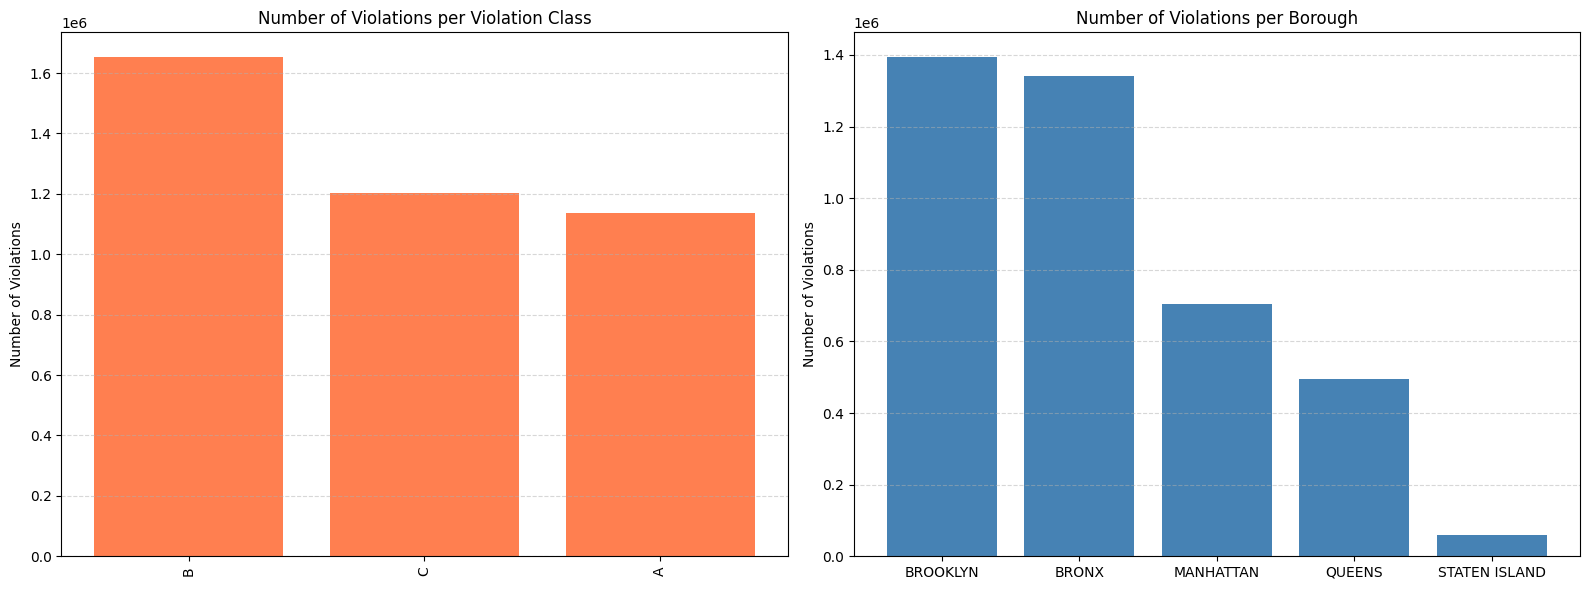

In [14]:
counts_class = df_violations["class"].value_counts()
comp_borough = df_violations["boro"].value_counts()

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.bar(counts_class.index, counts_class.values, color='coral')
plt.title("Number of Violations per Violation Class")
plt.ylabel("Number of Violations")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.bar(comp_borough.index, comp_borough.values, color='steelblue')
plt.title("Number of Violations per Borough")
plt.ylabel("Number of Violations")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

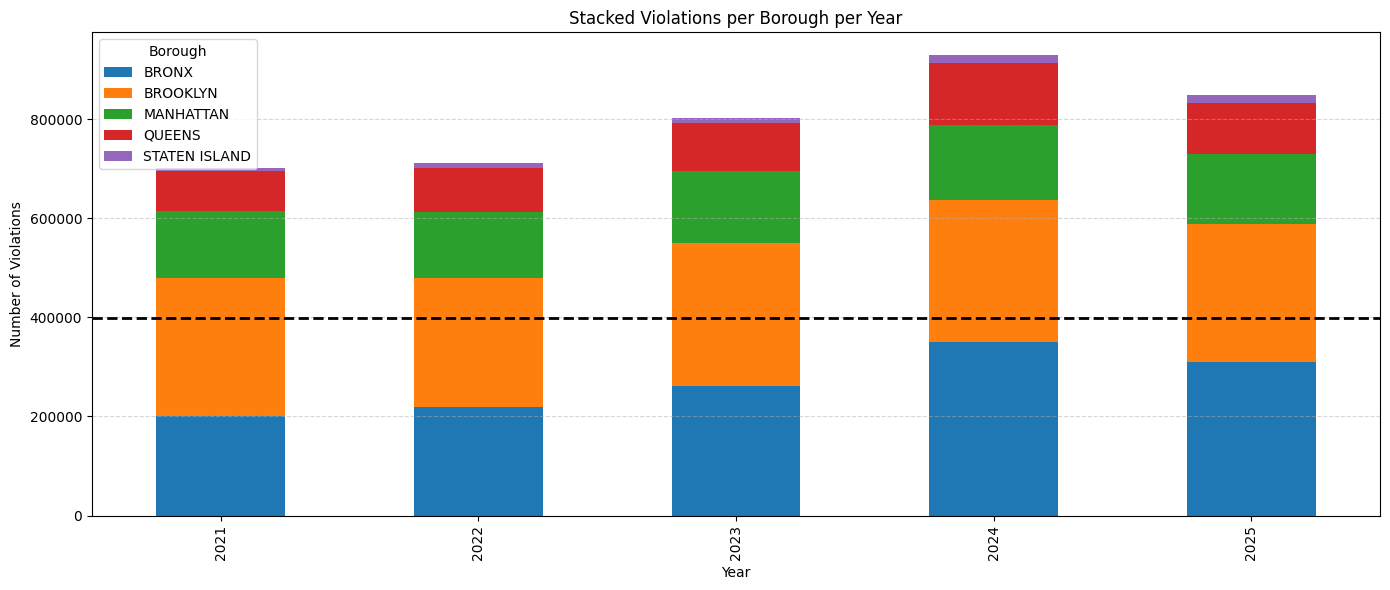

In [15]:
df_violations["year"] = df_violations["inspectiondate"].dt.year
year_boro = df_violations.groupby(["year", "boro"]).size().unstack(fill_value=0)
year_totals = year_boro.sum(axis=1)
ax = year_boro.plot(kind="bar", stacked=True, figsize=(14, 6))
ax.axhline(y=year_totals.mean() * 0.5, color="black", linestyle="--", linewidth=2)

plt.title("Stacked Violations per Borough per Year")
plt.xlabel("Year")
plt.ylabel("Number of Violations")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Borough")
plt.tight_layout()
plt.show()

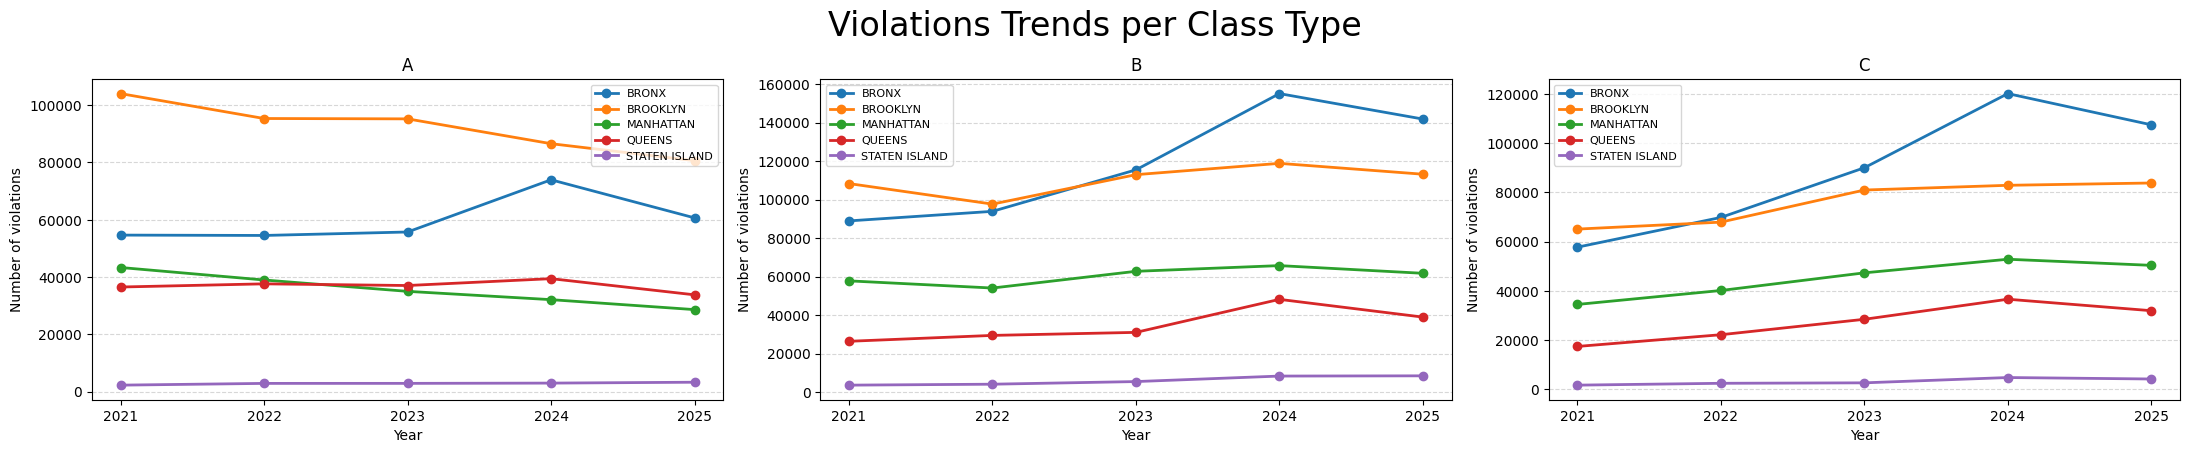

In [16]:
grouped = (df_violations.groupby(["boro", "year", "class"]).size().reset_index(name="count"))
classes = grouped["class"].unique()
years = sorted(grouped["year"].unique())

fig, axes = plt.subplots(2, 3, figsize=(22, 2 * 4))
axes = axes.flatten()

for i, comp in enumerate(classes):
    ax = axes[i]
    df_c = grouped[grouped["class"] == comp]

    for borough in df_c["boro"].unique():
        df_b = df_c[df_c["boro"] == borough]
        ax.plot(df_b["year"], df_b["count"], marker='o', linewidth=2, label=borough)

    ax.set_title(comp)
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of violations")
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_xticks(years)
    ax.legend(fontsize=8)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Violations Trends per Class Type", fontsize=24)
plt.tight_layout()
plt.show()

## 2.3. Registrations

In [17]:
df_registrations=pd.read_csv("data/registrations_original.csv")
df_registrations.head()

,registrationid,buildingid,boro,zip,lastregistrationdate
0,825850,271859,BROOKLYN,11234.0,2026-03-19T00:00:00.000
1,131572,169,MANHATTAN,10003.0,2025-08-13T00:00:00.000
2,109808,245,MANHATTAN,10028.0,2025-08-08T00:00:00.000
3,420463,810843,QUEENS,11434.0,2026-03-31T00:00:00.000
4,335058,383549,BROOKLYN,11231.0,2026-03-30T00:00:00.000


In [18]:
print("Missing values per column")
print(df_registrations.isna().sum())

Missing values per column
registrationid          0
buildingid              0
boro                    0
zip                     7
lastregistrationdate    0
dtype: int64


Drop rows with zip code as missing value. <br>
The repeated registration IDs means some building have the same owner (probably *Garden Complexes*)

In [19]:
df_registrations = df_registrations.dropna(subset=["zip"])
print(f"Number of observations: {len(df_registrations)}")
print(f"Number of unique registrationID: {len(df_registrations['registrationid'].unique())}")
print(f"Number of unique buildingID : {len(df_registrations['buildingid'].unique())}")
print(f"Number of unique boroughs: {len(df_registrations['boro'].unique())}\n")

print(f"Number of repeated registration IDs: {len(df_registrations) - len(df_registrations['registrationid'].unique())}")

Number of observations: 176069
Number of unique registrationID: 166416
Number of unique buildingID : 176063
Number of unique boroughs: 5

Number of repeated registration IDs: 9653


# 3. Data Analysis

## 3.1. Complaints and Violations counts normalized per population

The number of complaints and violations per borough and per zip should take into account population per borough and per zip, so that the comparision is fair. It was then computed per 1000 people for each borough and for each zip code, separately, since it is a more interpretable measure. The population by borough was fetched from [8] and by zip from [9].

In [20]:
df_pop_raw = pd.read_csv("data/nyc_demographics/New_York_City_Population_by_Borough,_1950_-_2040_20260512.csv")
df_pop_raw = df_pop_raw[df_pop_raw["Borough"] != "NYC Total"]
borough_pop = df_pop_raw.set_index("Borough")["2020"]
name_map = {
    "   Bronx":        "BRONX",
    "   Brooklyn":     "BROOKLYN",
    "   Manhattan":    "MANHATTAN",
    "   Queens":       "QUEENS",
    "   Staten Island": "STATEN ISLAND" 
}
borough_pop = borough_pop.str.replace(",", "").astype(int)
borough_pop.index = borough_pop.index.map(name_map)

For the **Complaints dataset**, Bronx keeps being the borough with higher values across year and type of complaint. Brooklyn and Manhattan now stay closer compared to the unnormalized plot.

In [21]:
borough_order = ["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"]
comp_borough = df_complaints["borough"].str.upper().value_counts().reindex(borough_order)
borough_pop = borough_pop.reindex(borough_order)

complaints_per_1000 = (comp_borough / borough_pop) * 1000
df_rates = pd.DataFrame({
    "complaints":          comp_borough,
    "population":          borough_pop,
    "complaints_per_1000": complaints_per_1000
})
df_rates

,complaints,population,complaints_per_1000
BRONX,860267,1446788,594.604738
BROOKLYN,704758,2648452,266.101859
MANHATTAN,535979,1638281,327.159382
QUEENS,325246,2330295,139.572887
STATEN ISLAND,41819,487155,85.843315


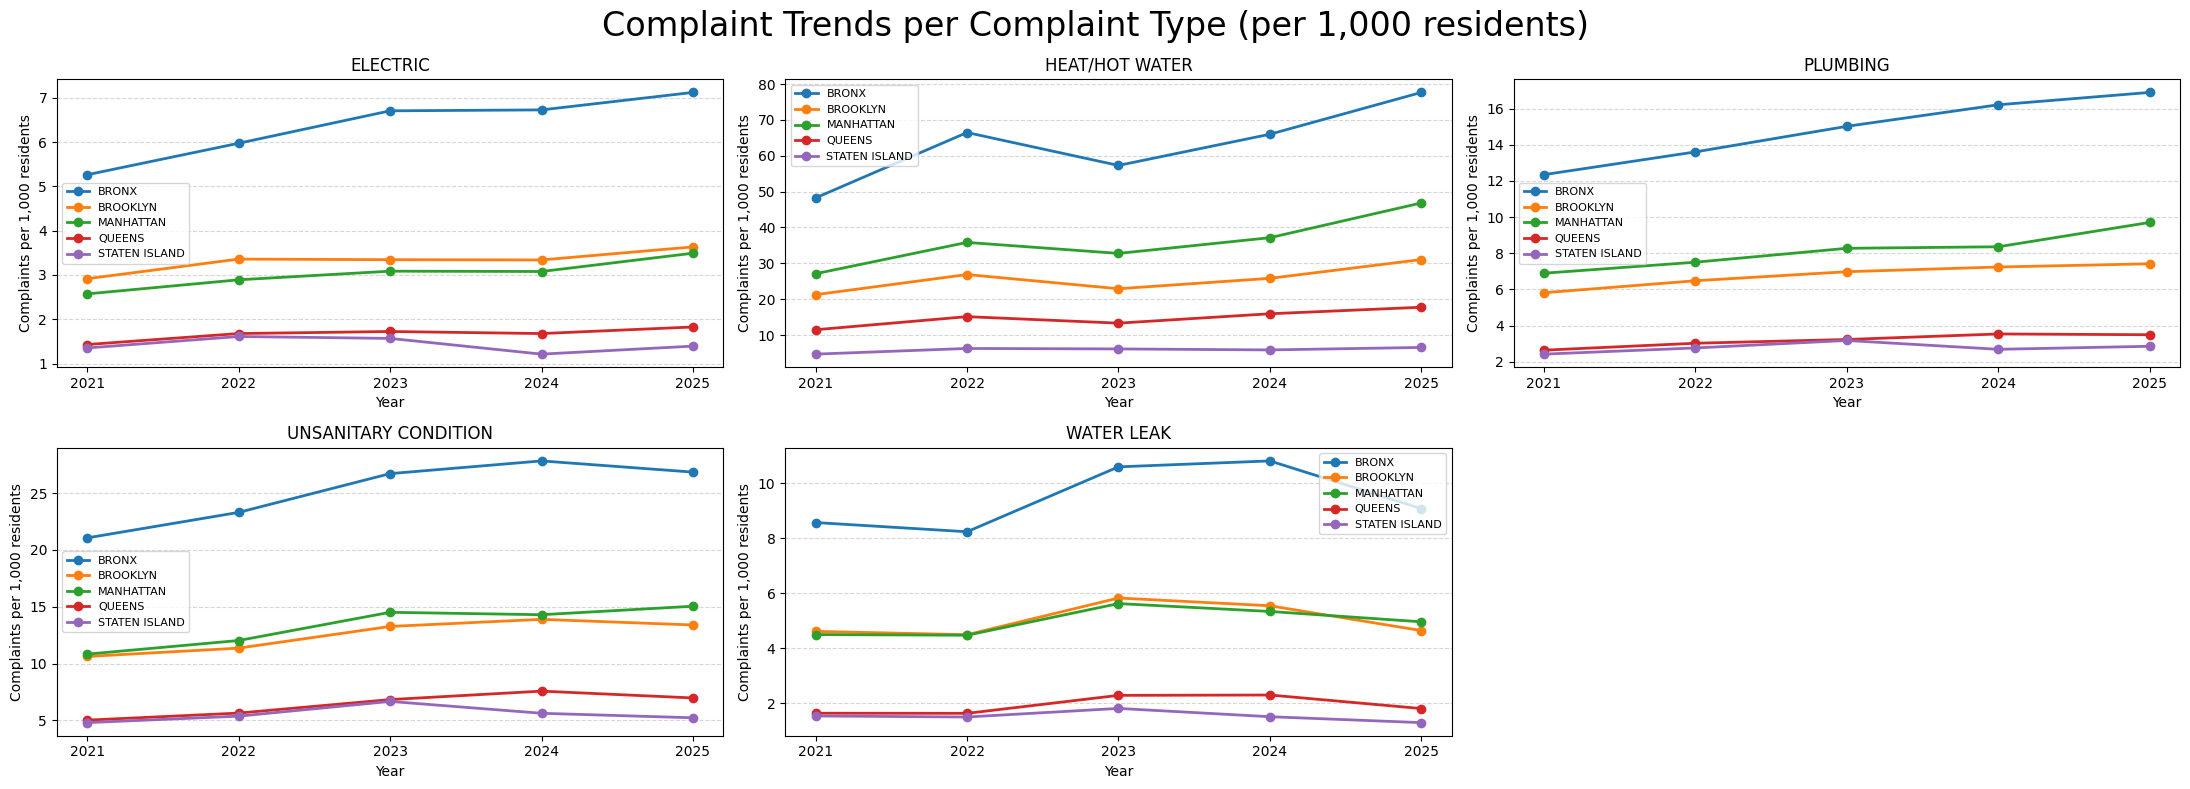

In [22]:
grouped = (df_complaints.groupby(["borough", "year", "complaint_type"]).size().reset_index(name="count"))

grouped["per_1000"] = grouped.apply(
    lambda row: (row["count"] / borough_pop[row["borough"].upper()]) * 1000,
    axis=1
)

complaints = grouped["complaint_type"].unique()
years = sorted(grouped["year"].unique())

fig, axes = plt.subplots(2, 3, figsize=(22, 2 * 4))
axes = axes.flatten()

for i, comp in enumerate(complaints):
    ax = axes[i]
    df_c = grouped[grouped["complaint_type"] == comp]

    for borough in df_c["borough"].unique():
        df_b = df_c[df_c["borough"] == borough]
        ax.plot(df_b["year"], df_b["per_1000"], marker='o', linewidth=2, label=borough)

    ax.set_title(comp)
    ax.set_xlabel("Year")
    ax.set_ylabel("Complaints per 1,000 residents")
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_xticks(years)
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Complaint Trends per Complaint Type (per 1,000 residents)", fontsize=24)
plt.tight_layout()
plt.show()

The complaints per zip per 1000 people are plotted with a choropleth plot saved in the `data/visualizations/complaints/zip_complaints_map.html`.

In [23]:
zip_pop = pd.read_csv("data/nyc_demographics/zipcode_populations.csv")
zip_pop["Population"] = zip_pop["Population"].str.replace(",", "").astype(int)

# complaints per zip
comp_zip=df_complaints["incident_zip"].value_counts()
comp_zip_df = comp_zip.rename_axis("Zip Code").reset_index(name="complaints")
comp_zip_pop = comp_zip_df.merge(zip_pop, on="Zip Code", how="left")

# complaints per 1000 people per zip
comp_zip_pop["complaints_1000"]=(comp_zip_pop["complaints"]/comp_zip_pop["Population"])*1000

In [24]:
min_range = comp_zip_pop["complaints_1000"].min()
max_range = comp_zip_pop["complaints_1000"].max()

with builtins.open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

with builtins.open("data/geojson/new-york-city-boroughs.geojson") as f:
    borough_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = str(feature["properties"]["postalCode"])

comp_zip_pop["Zip Code"] = comp_zip_pop["Zip Code"].astype(int).astype(str)

COLORSCALE = [
    [0.00, "#ffffff"], [0.07, "#fdecea"], [0.14, "#fadbd7"],
    [0.21, "#f5c4be"], [0.28, "#efada5"], [0.35, "#e8948a"],
    [0.42, "#df7b70"], [0.50, "#d46358"], [0.57, "#c84e42"],
    [0.64, "#bf3f33"], [0.71, "#b8352a"], [0.78, "#b43026"],
    [0.85, "#b22c22"], [0.92, "#b12821"], [1.00, "#b03020"]
]

fig = px.choropleth_mapbox(
    comp_zip_pop,
    geojson=zip_geo,
    locations="Zip Code",
    color="complaints_1000",
    color_continuous_scale=COLORSCALE,
    mapbox_style="carto-positron",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={"Zip Code": True, "complaints_1000": True},
    labels={"complaints_1000": "Complaints per 1,000 residents"}
)

fig.update_layout(
    margin={"r": 0, "t": 0, "l": 0, "b": 0},
    mapbox={
        "layers": [
            {
                "source": borough_geo,   
                "type": "line",          
                "color": "black",
                "line": {"width": 2},
            }
        ]
    }
)

fig.update_coloraxes(colorbar_title="Complaints per 1,000 residents")
fig.write_html("data/visualizations/complaints/zip_complaints_map.html")

C:\Users\Maria\AppData\Local\Temp\ipykernel_20908\405001834.py:24: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(


For the **Violations dataset**, Bronx is clearly more affected than the other boroughs across year and class of violation. 

In [25]:
viol_borough = df_violations["boro"].str.upper().value_counts().reindex(borough_order)
viol_per_1000 = (viol_borough / borough_pop) * 1000
df_viol = pd.DataFrame({
    "violations":          viol_borough,
    "population":          borough_pop,
    "viol_per_1000": viol_per_1000
})
df_viol

,violations,population,viol_per_1000
BRONX,1340141,1446788,926.287058
BROOKLYN,1393605,2648452,526.196057
MANHATTAN,705191,1638281,430.445693
QUEENS,494841,2330295,212.351226
STATEN ISLAND,59679,487155,122.505157


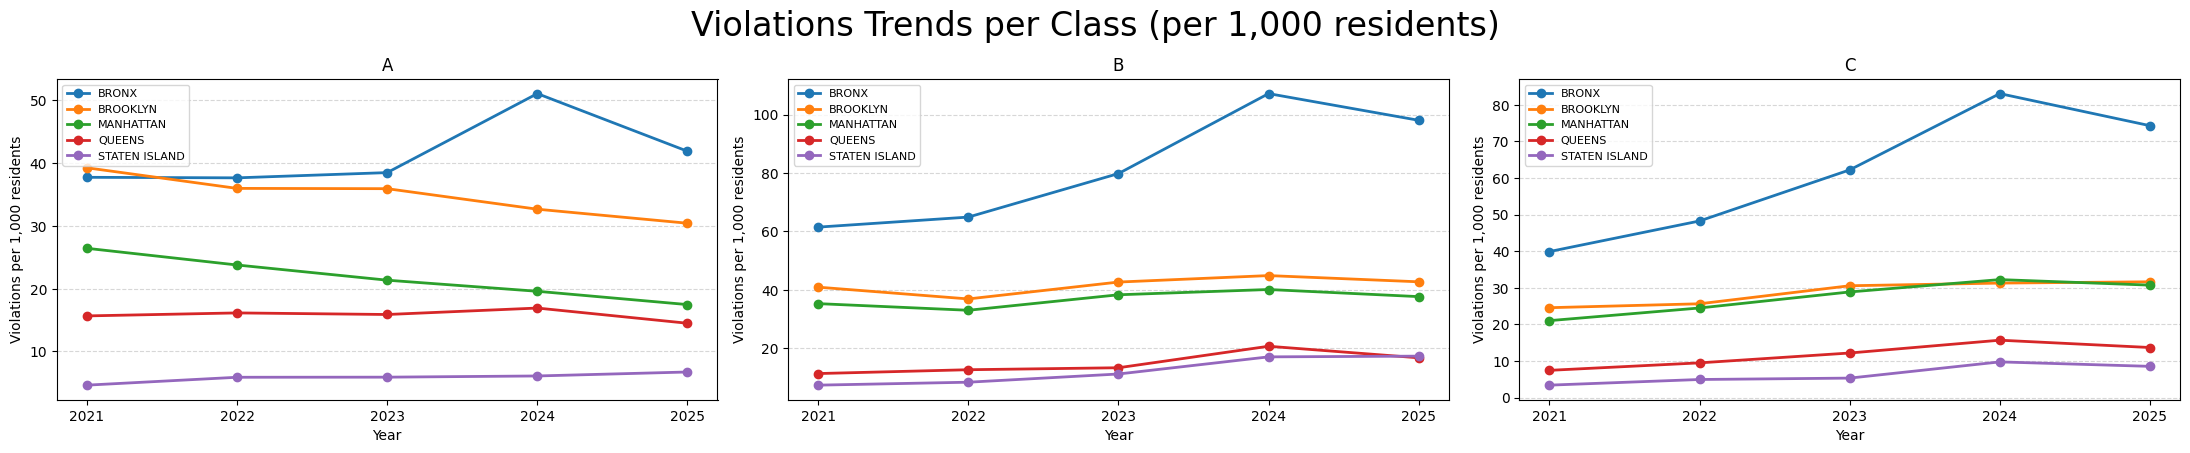

In [26]:
grouped_viol = (df_violations.groupby(["boro", "year", "class"]).size().reset_index(name="count"))

grouped_viol["per_1000"] = grouped_viol.apply(
lambda row: (row["count"] / borough_pop[row["boro"].upper()]) * 1000,
    axis=1
)

classes = grouped_viol["class"].unique()
years = sorted(grouped_viol["year"].unique())

fig, axes = plt.subplots(2, 3, figsize=(22, 2 * 4))
axes = axes.flatten()

for i, comp in enumerate(classes):
    ax = axes[i]
    df_c = grouped_viol[grouped_viol["class"] == comp]

    for borough in df_c["boro"].unique():
        df_b = df_c[df_c["boro"] == borough]
        ax.plot(df_b["year"], df_b["per_1000"], marker='o', linewidth=2, label=borough)

    ax.set_title(comp)
    ax.set_xlabel("Year")
    ax.set_ylabel("Violations per 1,000 residents")
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_xticks(years)
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Violations Trends per Class (per 1,000 residents)", fontsize=24)
plt.tight_layout()
plt.show()

The violations per zip per 1000 people are plotted with a choropleth plot saved in the `data/visualizations/violations/zip_violations_map.html`.

In [27]:
zip_pop = pd.read_csv("data/nyc_demographics/zipcode_populations.csv")
zip_pop["Population"] = zip_pop["Population"].str.replace(",", "").astype(int)

viol_zip=df_violations["zip"].value_counts()
viol_zip_df = viol_zip.rename_axis("Zip Code").reset_index(name="violations")
viol_zip_pop = viol_zip_df.merge(zip_pop, on="Zip Code", how="left")

viol_zip_pop["violations_1000"]=(viol_zip_pop["violations"]/viol_zip_pop["Population"])*1000

In [28]:
min_range=viol_zip_pop["violations_1000"].min()
max_range=viol_zip_pop["violations_1000"].max()

with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    viol_zip_pop,
    geojson=zip_geo,
    locations="Zip Code",
    color="violations_1000",
    color_continuous_scale=COLORSCALE,
    mapbox_style="carto-positron",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "Zip Code": True,
        "violations_1000": True
    },
    labels={
        "violations_1000": "Complaints",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Violations per 1000 residents")

fig.update_layout(
    margin={"r": 0, "t": 0, "l": 0, "b": 0},
    mapbox={
        "layers": [
            {
                "source": borough_geo,   
                "type": "line",          
                "color": "black",
                "line": {"width": 2},
            }
        ]
    }
)

fig.write_html("data/visualizations/violations/zip_violations_map.html")

C:\Users\Maria\AppData\Local\Temp\ipykernel_20908\449743510.py:11: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(


## 3.2. Income categories

Zip codes are grouped into four income categories based on their median income relative to the NYC median. The thresholds (50%, 80%, 120%) were chosen so that each category has a meaningful number of zip codes, so that we can compare across zip codes.

In [29]:
df_income=pd.read_csv("data/nyc_zipcode_income.csv")
df_income = df_income.drop(columns=["margin_of_error"])
df_income.head()

,location,median_income,zipcode,borough
0,ZCTA5 10282,250001,10282,Manhattan
1,ZCTA5 10004,250001,10004,Manhattan
2,ZCTA5 10007,250001,10007,Manhattan
3,ZCTA5 10279,250001,10279,Manhattan
4,ZCTA5 11030,234966,11030,Queens


In [30]:
print("Missing values per column")
print(df_income.isna().sum())

Missing values per column
location         0
median_income    0
zipcode          0
borough          0
dtype: int64


count       192.000000
mean     100357.432292
std       46545.619249
min       24086.000000
25%       69221.500000
50%       90393.500000
75%      122762.000000
max      250001.000000
Name: median_income, dtype: float64


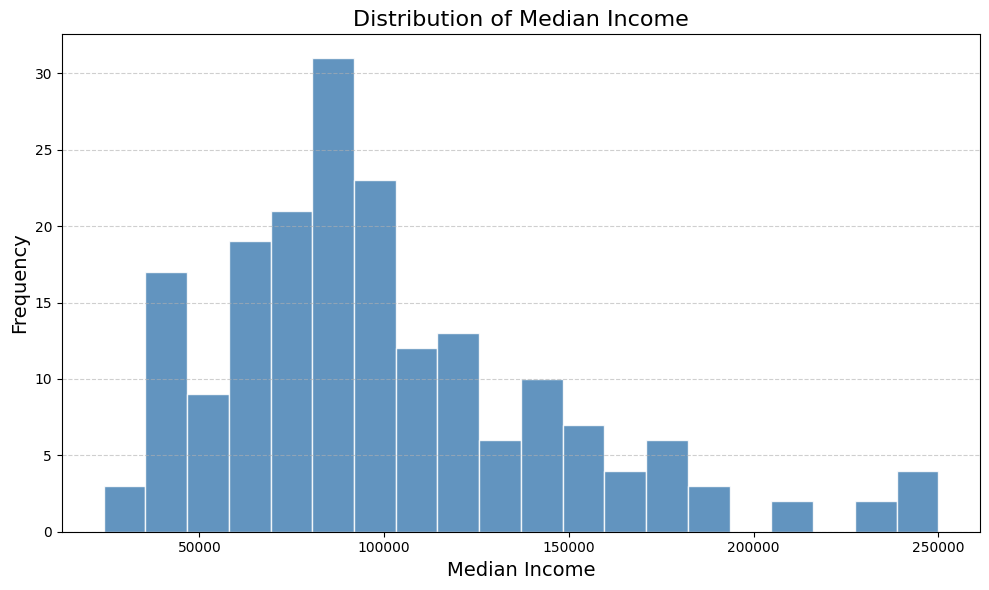

In [31]:
median_income=df_income["median_income"]
print(median_income.describe())

median_income = np.array(median_income)

plt.figure(figsize=(10, 6))
plt.hist(median_income, bins=20, color="steelblue", edgecolor="white", alpha=0.85)
plt.title("Distribution of Median Income", fontsize=16)
plt.xlabel("Median Income", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [32]:
city_median = df_income["median_income"].median()

bins = [0, 0.5 * city_median, 0.8 * city_median, 1.2 * city_median, float("inf")]
labels = ["Low", "Low-Middle", "Middle", "High"]

df_income["income_cat"] = pd.cut(df_income["median_income"], bins=bins, labels=labels, right=False)
df_income.to_csv("data/nyc_zipcode_income_class.csv", index=False)
print(df_income["income_cat"].value_counts())

income_cat
Middle        76
High          61
Low-Middle    37
Low           18
Name: count, dtype: int64


A choropleth plot with each zip as a income category is saved in the `data/visualizations/nyc_income_map.html`.

In [33]:
with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

df_income["zipcode"] = df_income["zipcode"].astype(str)
color_map = {
    "Low":         "#08306b",  # darkest
    "Low-Middle":  "#2171b5",
    "Middle":      "#6baed6",
    "High":        "#c6dbef"   # lightest
}

fig = px.choropleth_mapbox(
    df_income,
    geojson=zip_geo,
    locations="zipcode",
    color="income_cat",
    color_discrete_map=color_map,
    mapbox_style="carto-positron",
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zipcode": True,
        "median_income": ":,",
        "income_cat": True
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
    legend_title_text="Income Category"
)

fig.write_html("data/visualizations/nyc_income_map.html")

C:\Users\Maria\AppData\Local\Temp\ipykernel_20908\445050874.py:16: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(


## 3.3. Days to close a case

For violations with certified date, we will compute the days that it takes to close it as the difference between inspection date and certified date. Each violation will be assigned an income category based on its zip code and the four income groups defined above.

In [64]:
df_cert = df_violations[df_violations["certifieddate"].notna()]
df_cert["inspectiondate"] = pd.to_datetime(df_cert["inspectiondate"])
df_cert["certifieddate"]  = pd.to_datetime(df_cert["certifieddate"])
df_cert["days_to_certify"] = (df_cert["certifieddate"] - df_cert["inspectiondate"]).dt.days

df_income = pd.read_csv("data/nyc_zipcode_income_class.csv")
df_cert = df_cert.merge(df_income[['zipcode', 'income_cat']], left_on='zip',  right_on='zipcode', how='left').drop(columns='zipcode')
df_cert.head()

,violationid,zip,class,inspectiondate,certifieddate,boro,violationstatus,registrationid,year,days_to_certify,income_cat
0,18544103,11213,B,2025-12-31,2026-01-25,BROOKLYN,Close,300385,2025,25,Low-Middle
1,18544076,11213,A,2025-12-31,2026-01-25,BROOKLYN,Close,300385,2025,25,Low-Middle
2,18542105,11206,C,2025-12-31,2026-01-11,BROOKLYN,Close,300784,2025,11,Low-Middle
3,18541881,10467,C,2025-12-31,2026-01-13,BRONX,Close,226253,2025,13,Low-Middle
4,18541629,10301,B,2025-12-31,2026-02-10,STATEN ISLAND,Close,500154,2025,41,Middle


Then, the violations will be grouped by zip code so we can assess which zip codes have a higher median waiting time to close a violation.

In [79]:
cert_zip = df_cert.groupby("zip")["days_to_certify"].median().reset_index()
min_range=cert_zip["days_to_certify"].min()
max_range=cert_zip["days_to_certify"].max()
min_range, max_range

(np.float64(8.0), np.float64(107.0))

In [102]:
cert_zip["days_to_certify"].describe()

count    182.000000
mean      29.862637
std        9.243952
min        8.000000
25%       26.000000
50%       30.000000
75%       32.000000
max      107.000000
Name: days_to_certify, dtype: float64

The color scale is capped at the 95th percentile of days to certify to prevent a small number of extreme outliers from compressing the color range and obscuring variation across the majority of zip codes.

In [80]:
p95 = cert_zip["days_to_certify"].quantile(0.95)

with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    cert_zip,
    geojson=zip_geo,
    locations="zip",
    color="days_to_certify",
    mapbox_style="carto-positron",
    color_continuous_scale="RdYlGn_r",
    range_color=(min_range, max_range),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zip": True,
        "days_to_certify": True
    },
    labels={
        "days_to_certify": "days_to_certify",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Days to close")

borough_labels = [
    {"name": "BRONX",         "lon": -73.865, "lat": 40.837},
    {"name": "MANHATTAN",     "lon": -73.971, "lat": 40.779},
    {"name": "BROOKLYN",      "lon": -73.944, "lat": 40.650},
    {"name": "QUEENS",        "lon": -73.832, "lat": 40.700},
    {"name": "STATEN ISLAND", "lon": -74.151, "lat": 40.579},
]

for label in borough_labels:
    fig.add_trace(go.Scattermapbox(
        lon=[label["lon"]],
        lat=[label["lat"]],
        mode="text",
        text=[label["name"]],
        textfont=dict(size=14, color="white", family="Arial Black"),
        hoverinfo="skip",
        showlegend=False,
    ))

fig.write_html("data/visualizations/zip_days_all.html")

C:\Users\Maria\AppData\Local\Temp\ipykernel_6768\612440829.py:10: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(
C:\Users\Maria\AppData\Local\Temp\ipykernel_6768\612440829.py:45: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


## 3.4. Days waiting to close a case

For violations without certified date, we first need to filter for the ones that are still open to then  compute the days that the violation has been opened as the difference between the inspection date and 31/12/2025, the limit date when the data was fetched. Each violation will also be assigned an income category based on its zip code and the four income groups defined above.

In [81]:
df_nan = df_violations[df_violations["certifieddate"].isna()]
df_nan = df_nan.merge(df_income[['zipcode', 'income_cat']], left_on='zip',  right_on='zipcode', how='left').drop(columns='zipcode')

df_open = df_nan[df_nan["violationstatus"]=="Open"]
df_open["days_open"] = (pd.to_datetime("2025-12-31") - df_open["inspectiondate"]).dt.days
df_open.head()

,violationid,zip,class,inspectiondate,certifieddate,boro,violationstatus,registrationid,year,income_cat,days_open
2,18544150,11372,C,2025-12-31,NaT,QUEENS,Open,401100,2025,Middle,0
3,18544144,11372,C,2025-12-31,NaT,QUEENS,Open,401100,2025,Middle,0
4,18544049,10019,C,2025-12-31,NaT,MANHATTAN,Open,142112,2025,High,0
9,18549683,10455,C,2025-12-31,NaT,BRONX,Open,200220,2025,Low,0
11,18541608,10301,C,2025-12-31,NaT,STATEN ISLAND,Open,500154,2025,Middle,0


The violations will again be grouped by zip code so we can assess which zip codes have a higher median waiting time to close a violation.

In [87]:
open_zip = df_open.groupby("zip")["days_open"].median().reset_index()
min_range=open_zip["days_open"].min()
max_range=open_zip["days_open"].max()
min_range, max_range

(np.float64(124.0), np.float64(1526.0))

In [132]:
open_zip["days_open"].describe()

count     183.000000
mean      708.196721
std       170.379988
min       124.000000
25%       624.500000
50%       713.000000
75%       786.500000
max      1526.000000
Name: days_open, dtype: float64

In [88]:
p95 = open_zip["days_open"].quantile(0.95)

with open("data/geojson/nyc-zip-code-tabulation-areas-polygons.geojson") as f:
    zip_geo = json.load(f)

# overwrite feature["id"] with the ZIP code
for feature in zip_geo["features"]:
    feature["id"] = feature["properties"]["postalCode"]

fig = px.choropleth_mapbox(
    open_zip,
    geojson=zip_geo,
    locations="zip",
    color="days_open",
    mapbox_style="carto-positron",
    range_color=(min_range, p95),
    zoom=9,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    hover_data={
        "zip": True,
        "days_open": True
    },
    labels={
        "days_open": "days_open",
    }
)

fig.update_layout(
    margin={"r":0, "t":0, "l":0, "b":0},
)

fig.update_coloraxes(colorbar_title="Days Open")

borough_labels = [
    {"name": "BRONX",         "lon": -73.865, "lat": 40.837},
    {"name": "MANHATTAN",     "lon": -73.971, "lat": 40.779},
    {"name": "BROOKLYN",      "lon": -73.944, "lat": 40.650},
    {"name": "QUEENS",        "lon": -73.832, "lat": 40.700},
    {"name": "STATEN ISLAND", "lon": -74.151, "lat": 40.579},
]

for label in borough_labels:
    fig.add_trace(go.Scattermapbox(
        lon=[label["lon"]],
        lat=[label["lat"]],
        mode="text",
        text=[label["name"]],
        textfont=dict(size=14, color="white", family="Arial Black"),
        hoverinfo="skip",
        showlegend=False,
    ))

fig.write_html("data/visualizations/zip_open_all.html")

C:\Users\Maria\AppData\Local\Temp\ipykernel_6768\723970717.py:10: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(
C:\Users\Maria\AppData\Local\Temp\ipykernel_6768\723970717.py:44: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


## 3.5. Find registration IDs and that correspond to 20% of the violations

Grouping violations by registration ID allows us to see how many violations each registration has. Then we can see how many registration IDs make up 20% of the violations and check registrations associated with worse housing conditions.

The income category corresponding to the income group of the zip code of the violation is also added.

In [120]:
viol_reg = df_violations.groupby('registrationid').size().sort_values(ascending=False)

total_violations = len(df_violations)
cumulative_pct = viol_reg.cumsum() / total_violations

n_needed = (cumulative_pct <= 0.20).sum() + 1
# index of registration ID until 20% of violations
top_reg_ids = cumulative_pct[cumulative_pct <= 0.20].index
print(f"{n_needed} registration IDs have 20% of all violations")

df_top20 = df_violations[df_violations['registrationid'].isin(top_reg_ids)]

df_income = pd.read_csv("data/nyc_zipcode_income_class.csv")
df_top20 = df_top20.merge(df_income[['zipcode', 'income_cat']], left_on='zip',  right_on='zipcode', how='left').drop(columns='zipcode')

df_top20.head(5)

872 registration IDs have 20% of all violations


,violationid,zip,class,inspectiondate,certifieddate,boro,violationstatus,registrationid,year,income_cat
0,18557284,10029,C,2025-12-31,NaT,MANHATTAN,Close,139824,2025,Low
1,18544103,11213,B,2025-12-31,2026-01-25,BROOKLYN,Close,300385,2025,Low-Middle
2,18544076,11213,A,2025-12-31,2026-01-25,BROOKLYN,Close,300385,2025,Low-Middle
3,18541881,10467,C,2025-12-31,2026-01-13,BRONX,Close,226253,2025,Low-Middle
4,18549799,11372,C,2025-12-31,NaT,QUEENS,Open,410611,2025,Middle


For the registration IDs that make up 20% of violations, we get total violations per registration, discriminating the number of violations per each income category value. The numbers are higher for low income areas, showing that these are amongst the most neglected areas.

In [128]:
total = df_top20.groupby('registrationid').size().rename('total_violations')
by_income = df_top20.groupby(['registrationid', 'income_cat']).size().unstack(fill_value=0)
df_summary = pd.concat([total, by_income], axis=1).reset_index()
df_summary = df_summary.sort_values('total_violations', ascending=False).reset_index(drop=True)

print("High > 0:", (df_summary['High'] > 0).sum())
print("Middle > 0:", (df_summary['Middle'] > 0).sum())
print("Low-Middle > 0:", (df_summary['Low-Middle'] > 0).sum())
print("Low > 0:", (df_summary['Low'] > 0).sum())

df_summary.head()

High > 0: 8
Middle > 0: 185
Low-Middle > 0: 320
Low > 0: 361


,registrationid,total_violations,High,Low,Low-Middle,Middle
0,0,96183,6725,7657,30725,51075
1,374310,4398,0,0,4398,0
2,374351,3264,0,0,3264,0
3,221675,3254,0,3254,0,0
4,374352,2927,0,0,2927,0


## 3.6. Get contacts of top registration IDs

To identify who actually owns the buildings behind the top 20% of violations, we get their contacts, filtering to owner-type contacts only. We then create a standardized owner identifier using the corporation name for companies and the full name for individuals, and group registrations by owner identifier to find landlords who appear across more than one registration ID.

In [124]:
owner_types = ['CorporateOwner', 'Shareholder', 'IndividualOwner']
df_owners_top = df_contacts[(df_contacts['registrationid'].isin(top_reg_ids)) & (df_contacts['type'].isin(owner_types))]
print(df_owners_top["type"].value_counts())
df_owners_top.head()

type
CorporateOwner     865
Shareholder        177
IndividualOwner      7
Name: count, dtype: int64


,registrationcontactid,registrationid,type,corporationname,businessstreetname,businesshousenumber,firstname,lastname
492,11579703,115797,CorporateOwner,NORTHERN MAN EQUITIES,116 STREET,87-14,NaN,NaN
518,10732603,107326,CorporateOwner,PASCOL REALTY INC,TARRYTOWN ROAD,455,NaN,NaN
674,20524803,205248,CorporateOwner,686 E 234 REALTY LLC,STRATFORD RD,470,NaN,NaN
3490,50094410,500944,Shareholder,NaN,Northern Blvd,1044,Allan,Arker
3596,20700603,207006,CorporateOwner,643 SOUTHERN LLC,S BROADWAY,20,NaN,NaN


In [129]:
df_owners_top['match_key'] = df_owners_top.apply(lambda r: r['corporationname'] if r['type'] == 'CorporateOwner' else f"{r['firstname']} {r['lastname']}", axis=1)
df_owners_top['match_key'] = df_owners_top['match_key'].str.strip().str.upper()

owner_groups = df_owners_top.groupby('match_key')['registrationid'].apply(set).reset_index()
owner_groups.columns = ['match_key', 'registrationids']

shared_owners = owner_groups[owner_groups['registrationids'].apply(len) > 1]
print(f"{len(shared_owners)} owners appear across multiple registrations")

75 owners appear across multiple registrations


For the owners of multiple buildings identified above, we count how many buildings each owner has across all their registrations, and break that down by the income category of each building's zip code. This lets us see whether the worst landlords tend to own buildings concentrated in lower-income neighborhoods.

In [ ]:
df_registrations = df_registrations.merge(df_income[['zipcode', 'income_cat']], left_on='zip',  right_on='zipcode', how='left').drop(columns='zipcode')

buildings_per_reg = df_registrations.groupby('registrationid')['buildingid'].nunique()
shared_owners['total_buildings'] = shared_owners['registrationids'].apply(
    lambda ids: buildings_per_reg.reindex(ids).sum()
)

buildings_per_reg_income = df_registrations.groupby(['registrationid', 'income_cat'])['buildingid'].nunique().unstack(fill_value=0)
income_counts = shared_owners['registrationids'].apply(
    lambda ids: buildings_per_reg_income.reindex(ids).sum()
)

shared_owners = pd.concat([shared_owners, income_counts], axis=1)
shared_owners = shared_owners.sort_values('total_buildings', ascending=False).reset_index(drop=True)
shared_owners.head()

,match_key,registrationids,total_buildings,High,Low,Low-Middle,Middle
0,ZOHAR LEVY,"{326593, 201030, 203559, 305800, 202505, 21082...",15,0,12,3,0
1,ALEX ARKER,"{500928, 500943, 500944, 500945, 500976, 50098...",9,0,0,9,0
2,ALLAN ARKER,"{500928, 500943, 500944, 500945, 500976, 50098...",9,0,0,9,0
3,JOSEPH POPACK,"{306562, 301196, 306988, 300557, 302065, 30178...",8,0,0,3,5
4,ANTHONY GAZIVODA,"{200160, 201890, 200611, 204906, 203851, 22135...",7,0,3,3,1


We were then able to find the landlords that own buildings with the highest number of violations and where in the city these buildings are.

# 4. Genre

## 4.1 Visual Narrative (3 sub-categories)

### Visual Structuring
We used the same `carto-positron` base map with the same zoom level and centre point across all five choropleths, so the reader never has to re-orient when switching between maps. We also added black borough boundary lines as an overlay on every map. The analysis follows a linear section arc: raw counts → normalised rates → geographic maps → income stratification → resolution times → landlord analysis — which acts as a spatial and temporal scaffold for the reader.

### Highlighting
A consistent `borough_colors` dictionary is applied across every line chart, so the same borough always appears in the same colour regardless of which metric is being shown. For the choropleths, we used a custom white-to-dark-red `COLORSCALE` that makes the highest-burden zip codes stand out immediately. For the resolution-time maps, we capped the colour range at the 95th percentile to prevent extreme outliers from collapsing all other variation to near-white. Borough name labels are also overlaid as text traces on every map.

### Transition Guidance
The borough is the persistent unit of analysis across every chart type — from bar charts to line plots to choropleths — so the reader can always track the same entity across views. The same four income categories (Low, Low-Middle, Middle, High) introduced in the income analysis are reused without modification in the violations, landlord, and building ownership sections. The NYC map itself also serves as a familiar spatial anchor that reduces the cognitive load of interpreting geographic patterns.

---

## 4.2 Narrative Structure (3 sub-categories)

### Ordering
We followed a strict linear (martini-glass) path: Motivation → EDA → normalised rates → income weight → resolution times → landlord analysis. Each section deliberately builds on concepts introduced in the previous one, so the reader reaches the central conclusion only after seeing all the evidence that supports it.

### Interactivity
All five Plotly choropleth maps are exported as HTML files with hover detail-on-demand, showing zip code and the relevant metric on mouse-over. Zoom and pan are also enabled for intra-borough exploration. We deliberately avoided adding filtering widgets, as the target audience is non-technical and the author-curated views already surface the key comparisons.

### Messaging
Every chart is followed by an interpretive caption that states the takeaway in plain language. Chart titles include both the variable and the unit of measurement, making each figure self-describing. The thesis — that housing conditions are systematically worse in lower-income neighbourhoods — is stated explicitly in Section 1 before any data is shown. The landlord section at the end functions as a cumulative synthesis, converting aggregate geographic patterns into named actors to make the findings concrete and actionable.

# 4. Genre

## 4.1 Visual Narrative (3 sub-categories)

### Visual Structuring

The website follows a strict top-to-bottom scroll path divided into seven named sections — Introduction, Complaints, Violations, Income & Distress, Days to Close, Landlords, and Findings — each anchored in the sticky navigation bar. Every section opens with a **dark metric strip** on a `#1c1916` background that states the key numbers at a glance (e.g., *"2,468,069 complaints filed"* or *"Median time: 30 days"*), immediately grounding the reader before the prose begins. This dark/light alternation — dark strip → light narrative → light chart — repeats as a visual rhythm throughout the page, so the reader always knows where they are in the story.

All five interactive choropleth maps share the same `carto-positron` base map, the same zoom level (`9`) and the same centre point (`40.7128 N, 74.0060 W`), and all carry a black borough-boundary overlay layer. The reader never has to re-orient when switching between the complaints map, the income map, the violations map, and the two resolution-time maps.

### Highlighting

After each figure, a row of **callout boxes** (red, green, or amber top borders) restates the single most important number from that chart in plain language — for example, *"595 complaints per 1,000 residents"* in red for the Bronx, or *"The Blue Shield"* in green for high-income Manhattan zones. This separates the analytical interpretation from the chart itself and ensures a reader who only skims the callouts still absorbs the core message.

For all complaint and violation choropleths, a custom 16-stop white-to-dark-red `COLORSCALE` anchors white to the dataset minimum rather than zero, so variation is visible across the full zip-code range instead of collapsing into uniform light pink. The resolution-time maps switch to the semantically intuitive `RdYlGn_r` palette (red = slow, green = fast), and the *Days to Certify* scale is capped at its 95th percentile to prevent a handful of extreme outliers from compressing all other variation to near-white.

### Transition Guidance

The borough is the persistent unit of analysis from the first bar chart to the last choropleth. A single `borough_colors` dictionary drives every line chart, so Brooklyn is always the same colour regardless of whether the panel shows complaint types or violation classes — the reader learns the legend once and carries it forward. The same four income categories (Low, Low-Middle, Middle, High) introduced in the income strip reappear without modification in the violations, landlord table, and three-map comparisons. The income map itself is recycled as the **centre panel** of both three-map grids (Fig. 6 and Fig. 7), acting as a fixed spatial reference that makes the left and right panels immediately comparable by eye.

---

## 4.2 Narrative Structure (3 sub-categories)

### Ordering

The website follows a **linear martini-glass** path. The hero section opens with a single emotional hook (*"Every year, more than 300,000 people move to New York City in pursuit of a better life"*) before the dark introduction names the two data lenses — complaints and violations — and states the thesis explicitly. From there, the narrative moves in one direction: raw complaint volume (Fig. 1 calendar heatmap) → geographic concentration (Fig. 2 complaints map) → complaint type breakdown (Fig. 3 tabbed line charts) → violation scale (Fig. 4 stacked bar) → violation severity (Fig. 5 class line charts) → income overlap (Fig. 6 three-map grid) → resolution times (Fig. 7 three-map grid) → landlord accountability (Fig. 9 table) → conclusion. Each section builds on concepts introduced in the previous one; the income categories used in Fig. 6 are already familiar from the metric strip that precedes it.

### Interactivity

Three tab switchers handle temporal and categorical navigation without cluttering the page with simultaneous panels: a **year switcher** (2021–2025) on the calendar heatmap swaps five PNG images with a fade transition; a **complaint-type switcher** (Heat/Hot Water, Unsanitary, Water Leak, Plumbing, Electric) on Fig. 3 does the same for category line charts; and a **violation-class switcher** (Class A, B, C) on Fig. 5 steps through severity tiers. All five Plotly choropleth maps are embedded as iframes and expose hover detail-on-demand — zip code and the relevant metric on mouse-over — with zoom and pan enabled for intra-borough exploration. The landlord table (Fig. 9) is an interactive HTML iframe that is sortable by any column, letting the reader re-order by income category to verify the concentration claim themselves. Filtering widgets were deliberately excluded; the author-curated views already surface the key comparisons, and the target audience is non-technical.

### Messaging

Every section closes with one or two `story-body` paragraphs that state the takeaway in plain language, separate from the chart caption. The thesis — that housing conditions are systematically worse in lower-income neighbourhoods — is stated in the hero and reinforced at each stage: the complaints section ends by naming the Bronx as *"a different reality entirely"*; the violations section quantifies the Class C gap (*"83 per 1,000 residents vs. 32 in Manhattan"*); the income section calls the correlation *"consistent across every category, every year, and every severity class"*. The landlord section converts the aggregate geographic pattern into named actors — Zohar Levy, Alex Arker, Allan Arker, Joseph Popack — with their portfolio breakdowns by income category, making the argument concrete and actionable. The conclusion then ties all threads together in three short paragraphs before directing the reader to the full analysis notebook.

# 5. Visualizations
## Fig. 1 — Calendar Heatmap (Daily Complaint Volume, 2021–2025)

**What it is:** A `calplot` calendar heatmap — one cell per calendar day coloured by complaint volume, arranged in the familiar week/month grid. Five separate images (one per year) are presented via a tab switcher, so the reader can step through the time series without being overwhelmed by all five years at once.

**Why it works here:** The calendar heatmap is the ideal opener because it conveys two things simultaneously that a bar chart cannot — *volume* (colour intensity) and *seasonality* (the winter concentration of dark red squares). A reader who has never heard of HPD complaints immediately grasps that the heating crisis is cyclical and predictable, making the "A System at the Breaking Point" headline feel credible before any statistics are shown. The familiar visual grammar of a calendar (everyone has seen one) removes the cognitive overhead of learning a new chart type, which is important for a non-technical audience. The tab interaction adds a temporal dimension without requiring a complex multi-year overlay.

---

## Fig. 2 — Complaints per 1,000 Residents Choropleth Map (Interactive)

**What it is:** An interactive Plotly choropleth of all 211 NYC zip codes, coloured by complaint density (complaints per 1,000 residents), with borough boundaries drawn as a black overlay layer and hover tooltips showing the exact zip code and rate.

**Why it works here:** After the calendar establishes that complaints are large in number and seasonal, the map answers *where*. A map is the only chart type that can simultaneously show all 211 zip codes without aggregating them into bars — it preserves the geographic signal that is the central argument of the project (distress is spatially concentrated, not randomly distributed). The choropleth makes the Bronx's concentration of dark-red cells legible at a glance, while hover interactivity gives analytically curious readers the ability to verify specific zip codes without cluttering the main view.

---

## Fig. 3 — Complaints by Category and Borough (Tabbed Line Charts)

**What it is:** Five static PNG line plots — one per complaint type (Heat/Hot Water, Unsanitary, Water Leak, Plumbing, Electric) — presented via a tab switcher. Each chart shows complaints per 1,000 residents per year (2021–2025) with one line per borough, coloured by a consistent `borough_colors` dictionary.

**Why it works here:** Fig. 2 established *where* the distress is; Fig. 3 explains *what kind*. A line chart across years is the right encoding for a temporal trend question. The tab switcher enforces category comparison without overlapping five categories in a single panel (which would produce spaghetti lines). By normalising per 1,000 residents, the chart removes population size as a confound, so the Bronx line being highest reflects genuine density, not simply borough size. The consistent colour per borough is the key design choice — the reader only has to learn which colour is which once (from Fig. 3's legend), and that mapping carries forward to Fig. 5.

---

## Fig. 4 — Stacked Violations by Borough per Year (Static Bar Chart)

**What it is:** A stacked bar chart (static PNG, produced by `matplotlib`) showing the total number of violations per year (2021–2025) with each bar coloured by borough.

**Why it works here:** The stacked bar is the right encoding for answering "how does the total grow over time, and which borough contributes most?" It makes both the city-wide trend (total bar height rises sharply to 2024) and the borough composition (Bronx + Brooklyn consistently form the majority) simultaneously readable. A grouped bar chart would show borough comparisons more precisely but would lose the "total is growing" signal. A line chart would lose the compositional breakdown. The stacked bar is the natural compromise. The dashed line at 400,000 violations acts as an explicit annotation that anchors the reader's judgment — "the Bronx alone is approaching this threshold."


---

## Fig. 5 — Violation Density by Severity Class (Tabbed Line Charts)

**What it is:** Three static PNG line charts — one per violation class (A, B, C) — presented via a tab switcher. Each shows violations per 1,000 residents per year per borough, using the same `borough_colors` as Fig. 3.

**Why it works here:** Severity is the dimension that transforms "the Bronx has more violations" into "the Bronx has more *life-threatening* violations." The tab structure enforces a comparison across severity tiers — moving from Class A (non-hazardous, where boroughs cluster together) to Class C (immediately hazardous, where the Bronx breaks away dramatically). This sequential revelation is persuasive: the reader sees that the Bronx lead is not merely a bureaucratic artefact (Class A noise) but a genuine concentration of the most dangerous conditions. The same colour scheme as Fig. 3 lets the reader carry their borough-colour memory forward without re-learning the legend.


---

## Fig. 6 — The Triple Threat: Three-Map Side-by-Side Comparison (Interactive)

**What it is:** Three interactive Plotly choropleth iframes displayed side by side using a CSS `grid-template-columns: 1fr 1fr 1fr` layout: (1) Complaints per 1,000 residents, (2) Income category by zip code (Low / Low-Middle / Middle / High), (3) Violations per 1,000 residents. Each iframe is scaled to 67% of its native size via `transform: scale(0.667)` to fit the three-column layout while preserving full interactivity.

**Why it works here:** The three-map layout makes a causal argument visually — low income (centre) predicts high complaints (left) *and* high violations (right) — without requiring the reader to compute a correlation coefficient. Side-by-side spatial alignment is uniquely effective for this claim because the geographic signal (the same Bronx zip codes are dark in all three maps) would be invisible in any non-geographic chart type. The choice to reuse the same maps already introduced in Figs. 2 and 3.2 respects the reader's familiarity and avoids introducing new data that requires re-orientation. This is the narrative pivot of the website — everything before establishes the *what*; Fig. 6 establishes the *why*.

---

## Fig. 7 — Administrative Stagnation vs. Economic Reality: Three-Map Comparison (Interactive)

**What it is:** Another three-map grid, this time showing: (1) Median days a violation stays open (unresolved), (2) Median household income, (3) Median days to certify a closure. The "Days Open" map uses the `RdYlGn_r` scale (red = long wait, green = short wait); the income map is the same as Fig. 6; the "Days to Certify" map uses `RdYlGn_r` as well. The colour scale for Days to Certify is capped at the 95th percentile.

**Why it works here:** Figs. 2–6 establish that low-income areas have more problems. Fig. 7 asks whether those areas also *wait longer* for resolution — adding a temporal injustice dimension on top of the volumetric one. The three-map layout mirrors Fig. 6 structurally, which the reader has already learned to interpret, reducing cognitive load. Reusing the income map as the centre panel is intentional — it is the fixed reference point that makes both the "Days Open" and "Days to Certify" comparisons legible in a single glance. The RdYlGn_r palette (red = slow, green = fast) is semantically intuitive: red zones are danger zones in both the violation density maps and the waiting-time maps, maintaining colour-meaning consistency.

---

## Fig. 9 — The Worst Offenders: Sortable Landlord Table (Interactive)

**What it is:** An interactive HTML table (embedded as an iframe from `visualizations/owners_table.html`) listing the 75 owners who own buildings across more than one registration ID within the top-20%-of-violations group. Columns include total buildings and a breakdown of buildings by income category (Low, Low-Middle, Middle, High). The table is sortable.

**Why it works here:** All previous figures describe housing distress as a geographic and systemic pattern. The table names specific actors — "Zohar Levy", "Alex Arker", "Allan Arker", "Joseph Popack" — converting an abstract structural problem into identifiable human accountability. This is the culminating message of the narrative: the pattern is not random, it is the product of deliberate portfolio management by a small number of landlords concentrated almost exclusively in low-income zip codes. A table is the right format here because the reader's question has shifted from "which areas are worst?" (answered by maps) to "who is responsible and how many buildings do they own?" — a question that requires precise, comparable numbers for named entities. The interactive sort allows a reader to reorder by income category (e.g., sort by Low to confirm that worst offenders overwhelmingly operate in low-income zip codes), supporting exploratory engagement beyond the author-curated default view.



# 6. Discussion

Regarding positive aspects of the project, the multi-layered story would be the principal one, where the combination of five datasets allowed us to explore multiple perspectives on the housing situation in New York City, from raw complaint counts to normalized rates, landlord-level patterns, and income correlations. The landlord analysis added an original angle beyond borough-level comparisons, making it possible to identify specific owners who consistently accumulate violations across multiple buildings. The choropleth maps by zip code are effective at communicating geographic inequality in a visual way and in more detail than borough-level plots alone, helping the end user understand the spatial dimension of the problem. The overall data narrative follows a clear progression, from registered complaints, to violation severity, to days necessary to close a case, and finally to the landlord and income analysis.

Some aspects could be improved with more time and resources. The borough population is fixed at the 2020 Census figures across all years, meaning population growth between 2020 and 2025 is not reflected in the normalized rates. Similarly, the zip code population does not come from an official Census estimate but from a third-party source, which introduces some uncertainty in the zip-level normalization. The analysis identifies a consistent relationship between neighborhood income and housing enforcement outcomes, but does not establish a possible cause. Finally, the landlord analysis relies on string matching of owner names to deduplicate across registrations, which may miss owners who use slightly different name variations, or incorrectly merge owners who share a common name. A more robust entity resolution approach would improve the reliability of this part of the analysis.

# 7. Contributions

The student Maria Vendas was more focused on fetching the data sets and on the exploratory data analysis, while Diogo Forte focused on the story narrative and website structure. For the data analysis, the work was evenly split, since it also required more discussion.

# 8. References 

[1] NYC Open Data. (n.d.). *NYC Open Data portal*. City of New York. https://opendata.cityofnewyork.us

[2] U.S. Census Bureau. (n.d.). *American Community Survey (ACS)*. https://www.census.gov/programs-surveys/acs

[3] NYC Open Data. (2025). *311 Service Requests from 2010 to Present* [Dataset]. Department of Information Technology and Telecommunications (DoITT). https://data.cityofnewyork.us/resource/erm2-nwe9

[4] NYC Open Data. (2025). *Housing Maintenance Code Violations* [Dataset]. Department of Housing Preservation and Development. https://data.cityofnewyork.us/resource/wvxf-dwi5

[5] NYC Open Data. (2025). *Multiple Dwelling Registrations* [Dataset]. Department of Housing Preservation and Development. https://data.cityofnewyork.us/resource/tesw-yqqr

[6] NYC Open Data. (2025). *Registration Contacts* [Dataset]. Department of Housing Preservation and Development. https://data.cityofnewyork.us/resource/feu5-w2e2

[7] U.S. Census Bureau. (2024). *American Community Survey 5-year estimates, subject table S1901: Income in the past 12 months* [Dataset]. https://data.census.gov/table/ACSST5Y2024.S1901

[8] NYC Open Data. (2020). *New York City population by borough, 1950–2040* [Dataset]. Department of City Planning. https://data.cityofnewyork.us/City-Government/New-York-City-Population-by-Borough-1950-2040/xywu-7bv9

[9] New York Demographics. (n.d.). *New York zip codes by population* [Dataset]. https://www.newyork-demographics.com/zip_codes_by_population